In [1]:
import os
import sys
import json
project_dir = os.path.dirname(os.getcwd())
sys.path.append(project_dir)

import numpy as np

import torch
import torch.nn.functional as F
from torch import nn
from torch.utils.data import DataLoader

device = 'cuda' if torch.cuda.is_available() else 'cpu'
seed = torch.Generator().manual_seed(42)
print(device)

cuda


In [2]:
from data.cifar10 import get_cifar10_pipeline

train_loader, val_loader, test_loader = get_cifar10_pipeline(batch_size=128, indexed=True)
sample_x, sample_y = next(iter(train_loader))
print(sample_x.shape)
print(sample_y.shape)

torch.Size([128, 3, 32, 32])
torch.Size([128])


In [3]:
!pip install torchmetrics

In [4]:
!pip install torchinfo

In [5]:
!pip install fvcore

In [6]:
import torch
import torch.nn.functional as F
import tqdm

def self_distillation_loss(outputs, student_features, teacher_features, labels, alpha, lambda_val, temperature=1.0, bottleneck_dim=128):
    """
    Calculates the self-distillation loss.

    Args:
        outputs (list of torch.Tensor): output logits from each classifier
        student_features (list of torch.Tensor): feature maps after the bottleneck for each shallow classifier
        teacher_features (list of torch.Tensor): feature maps from the teacher network
        labels (torch.Tensor): ground truth labels
        alpha (float): used in KL divergence
        lambda_val (float): used in L2 loss
        temperature (float): temperature used for softmax in KL divergence
        bottleneck_dim (int): output dimension of the student bottleneck layers
    Returns:
        torch.Tensor: total self-distillation loss (sum of KL divergence loss, L2 Loss, and Cross Entropy)
    """
    num_classifiers = len(outputs)
    teacher_output = outputs[-1]
    total_loss = 0

    # iterate through shallow classifiers (student layers)
    for i in range(num_classifiers - 1):
        student_output = outputs[i]
        student_feat = student_features[i]
        teacher_feat = teacher_features[i]

        cross_entropy = F.cross_entropy(student_output, labels)

        # apply 1x1 conv to teacher features to match student bottleneck dimension
        teacher_bottleneck = nn.Conv2d(teacher_feat.shape[1], bottleneck_dim, kernel_size=1, bias=False).to(teacher_feat.device)
        teacher_feat_processed = teacher_bottleneck(teacher_feat)

        # make sure feature maps have compatible spatial shapes for L2 loss
        if student_feat.shape[2:] != teacher_feat_processed.shape[2:]:
            student_feat = F.adaptive_avg_pool2d(student_feat, teacher_feat_processed.shape[2:])
            teacher_feat_processed = F.adaptive_avg_pool2d(teacher_feat_processed, student_feat.shape[2:])

        # compute kl divergence loss
        kl_loss = F.kl_div(F.log_softmax(student_output / temperature, dim=1),
                          F.softmax(teacher_output / temperature, dim=1),
                          reduction='batchmean') * (temperature ** 2)

        # compute L2 loss
        l2_loss = F.mse_loss(student_feat, teacher_feat_processed)

        # sum together for all shallow classifiers (student models)
        # equation from paper 3
        total_loss += (1 - alpha) * cross_entropy + alpha * kl_loss + lambda_val * l2_loss

    # add cross-entropy loss for the teacher (deepest layer)
    total_loss += F.cross_entropy(teacher_output, labels)

    return total_loss

In [7]:
import torch.optim as optim
from torch.optim import lr_scheduler

from models.resnet_selfdistill import resnet34_sd

num_classes = 10
teacher = resnet34_sd(num_classes=num_classes).to(device)

# optimizer = optim.SGD(teacher.parameters(), lr=0.05, momentum=0.9, weight_decay=1e-5)
optimizer = optim.Adam(teacher.parameters(), lr=0.001)
scheduler = lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.1)

# hyperparameters for self-distillation
alpha = 0.3
lambda_val = 0.03
temperature = 3.0

teacher_path = f'models/weights/cifar10_resnet34_sd_teacher.pth'

In [8]:
def train_model(train_loader: DataLoader, model: nn.Module, optimizer: optim.Optimizer,
                epoch: int, alpha: float, lambda_val: float, temperature: float,
                device: str='cpu') -> float:
    """
    Train the model for one epoch using self-distillation loss.
    """
    model.train()
    epoch_loss = 0
    correct = 0
    total = 0
    for data, target in tqdm.tqdm(train_loader, desc=f'Epoch {epoch} training...', file=sys.stdout):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        outputs, student_features, teacher_features = model(data)
        loss = self_distillation_loss(outputs, student_features, teacher_features, target, alpha, lambda_val, temperature)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        _, predicted = outputs[-1].max(1) # Get predictions from the deepest classifier
        total += target.size(0)
        correct += predicted.eq(target).sum().item()

    avg_loss = epoch_loss / len(train_loader)
    avg_accuracy = 100. * correct / total
    print(f'Epoch {epoch} Average Loss: {avg_loss:.4f}, Average Accuracy: {avg_accuracy:.2f}%')
    return avg_loss

In [9]:
def evaluate_model(val_loader: DataLoader, model: nn.Module, device: str='cpu') -> float:
    """
    Evaluate the model on validation data.
    """
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in tqdm.tqdm(val_loader, desc='evaluating...', file=sys.stdout):
            data, target = data.to(device), target.to(device)
            outputs, _, _ = model(data)
            _, predicted = outputs[-1].max(1)
            total += target.size(0)
            correct += predicted.eq(target).sum().item()
    accuracy = 100. * correct / total
    print(f'Accuracy on the evaluation set: {accuracy:.2f}%')
    return accuracy

def train_val(train_loader, val_loader, model, optimizer, scheduler, alpha, lambda_val, temperature,
              device='cpu', path="./temp.pth", patience=50, epochs=50):
    metrics = {"train_loss": [], "accuracy": []}
    best_val_acc = 0
    counter = 0
    for epoch in range(1, epochs + 1):
        train_loss = train_model(train_loader, model, optimizer, epoch, alpha, lambda_val, temperature, device)
        val_accuracy = evaluate_model(val_loader, model, device)
        metrics['train_loss'].append(train_loss)
        metrics['accuracy'].append(val_accuracy)

        if val_accuracy >= best_val_acc:
            best_val_acc = val_accuracy
            counter = 0
            print(f"Epoch {epoch}: New best accuracy: {best_val_acc:.4f} saving model...")
            state = {
                'epoch': epoch,
                'state_dict': model.state_dict(),
                'optimizer': optimizer.state_dict(),
                'accuracy': val_accuracy,
                'train_loss': train_loss
            }
            torch.save(state, path)
        else:
            counter += 1
        if counter >= patience:
            print(f"Epoch {epoch}: Early stop triggered.")
            break
        if scheduler is not None:
            scheduler.step() # Assuming StepLR or similar

    return metrics

Epoch 1 training...: 100%|██████████| 391/391 [01:40<00:00,  3.90it/s]
Epoch 1 Average Loss: 5.4580, Average Accuracy: 38.62%
evaluating...: 100%|██████████| 16/16 [00:01<00:00, 11.89it/s]
Accuracy on the evaluation set: 47.85%
Epoch 1: New best accuracy: 47.8500 saving model...
Epoch 2 training...: 100%|██████████| 391/391 [01:41<00:00,  3.84it/s]
Epoch 2 Average Loss: 4.1088, Average Accuracy: 55.77%
evaluating...: 100%|██████████| 16/16 [00:01<00:00, 12.03it/s]
Accuracy on the evaluation set: 57.65%
Epoch 2: New best accuracy: 57.6500 saving model...
Epoch 3 training...: 100%|██████████| 391/391 [01:41<00:00,  3.85it/s]
Epoch 3 Average Loss: 3.4858, Average Accuracy: 63.52%
evaluating...: 100%|██████████| 16/16 [00:01<00:00, 12.00it/s]
Accuracy on the evaluation set: 61.80%
Epoch 3: New best accuracy: 61.8000 saving model...
Epoch 4 training...: 100%|██████████| 391/391 [01:41<00:00,  3.84it/s]
Epoch 4 Average Loss: 3.1065, Average Accuracy: 68.08%
evaluating...: 100%|██████████| 16

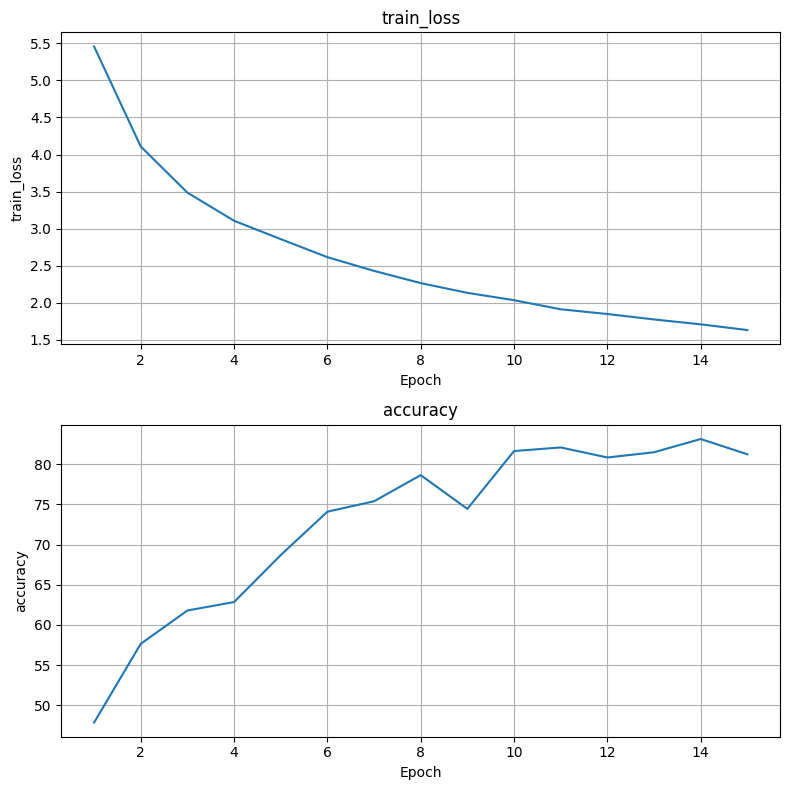

In [10]:
import tqdm
import sys
import torch.nn.functional as F
from models.resnet_selfdistill import resnet34_sd  # Import the self-distillation model
from utils.plots import plot_training_metrics

metrics_teacher = train_val(train_loader, val_loader, teacher, optimizer, scheduler,
                            alpha, lambda_val, temperature,
                            device=device, path=teacher_path, patience=50, epochs=15)

plot_training_metrics(metrics_teacher)

with open(os.path.join(project_dir, 'data/cifar10_resnet34_sd_teacher.json'), 'w') as f:
    json.dump(metrics_teacher, f)